In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import cv2
from skimage import exposure, filters, color
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns

print(" OpenCV     :", cv2.__version__)
print(" TensorFlow :", tf.__version__)
print(" NumPy      :", np.__version__)
print(" GPU        :", tf.config.list_physical_devices('GPU'))

 OpenCV     : 4.13.0
 TensorFlow : 2.19.0
 NumPy      : 2.0.2
 GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [6]:
DATA_DIR = "/kaggle/input/datasets/abdallahalidev/plantvillage-dataset/color"
classes = sorted(os.listdir(DATA_DIR))
print(f" Classes found: {len(classes)}")

 Classes found: 38


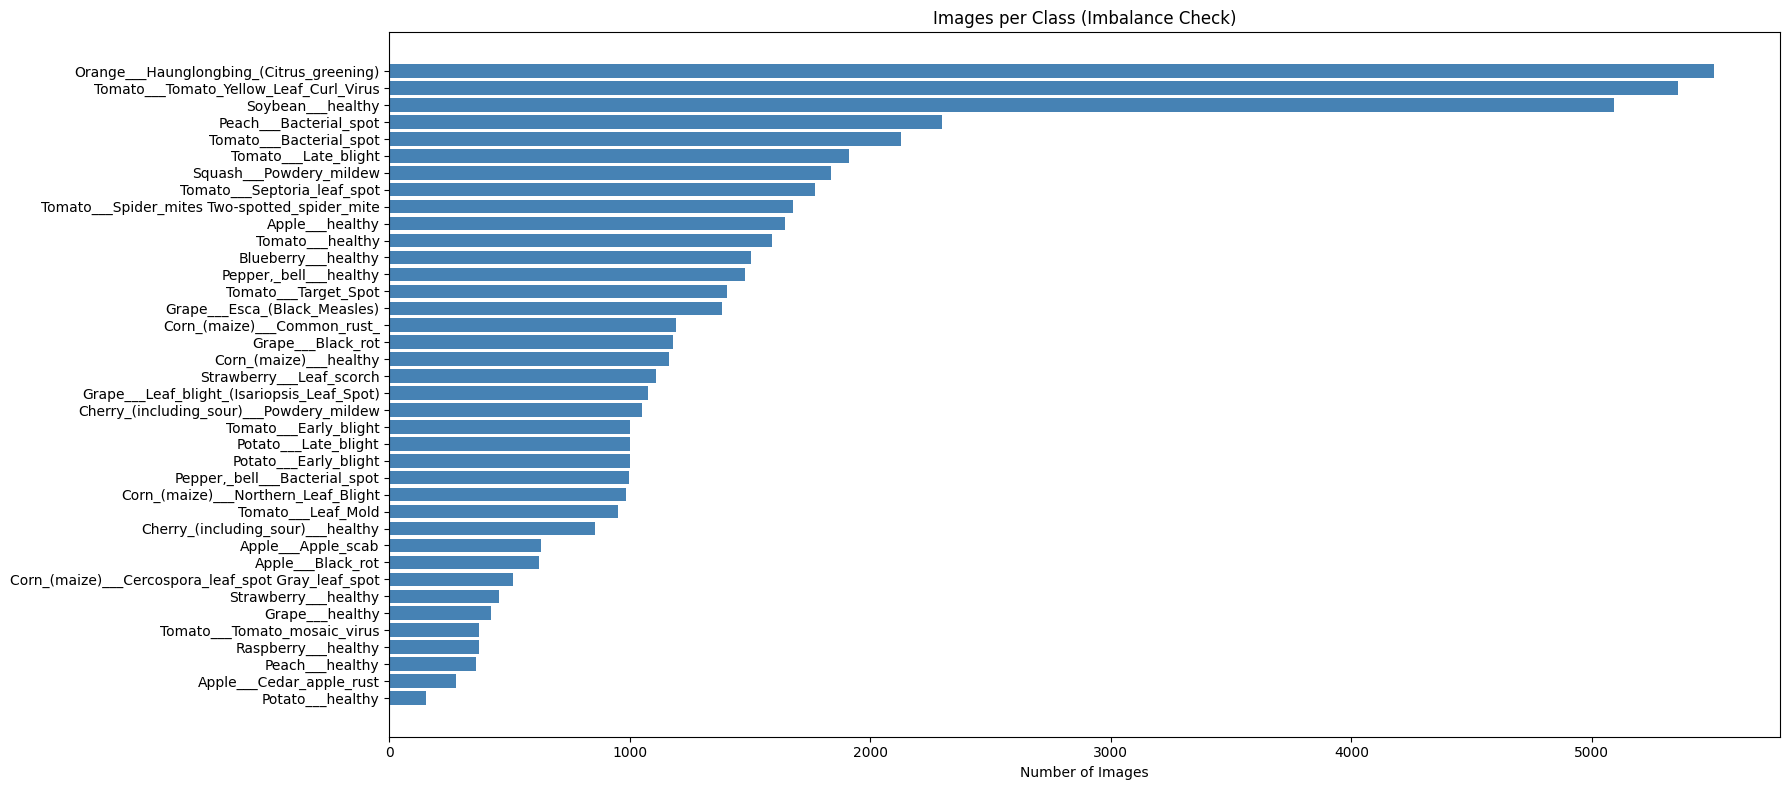

Max images in a class : 5507
Min images in a class : 152
Average per class     : 1429
Total images          : 54305


In [13]:
class_counts = {}
for class_name in classes:
    class_path = os.path.join(DATA_DIR, class_name)
    count = len(os.listdir(class_path))
    class_counts[class_name] = count

class_counts = dict(sorted(class_counts.items(), key=lambda x: x[1]))

plt.figure(figsize=(18, 8))
plt.barh(list(class_counts.keys()), list(class_counts.values()), color='steelblue')
plt.xlabel("Number of Images")
plt.title("Images per Class (Imbalance Check)")
plt.tight_layout()
plt.show()

counts = list(class_counts.values())
print(f"Max images in a class : {max(counts)}")
print(f"Min images in a class : {min(counts)}")
print(f"Average per class     : {int(sum(counts)/len(counts))}")
print(f"Total images          : {sum(counts)}")

In [7]:
all_labels = []
for idx, class_name in enumerate(classes):
    class_path = os.path.join(DATA_DIR, class_name)
    count = len(os.listdir(class_path))
    all_labels.extend([idx] * count)

all_labels = np.array(all_labels)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(all_labels),
    y=all_labels
)
class_weight_dict = dict(enumerate(class_weights))
print(" Class weights computed!")

 Class weights computed!


In [8]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names

# Split val into val + test
val_batches = len(val_ds)
test_size   = val_batches // 2
test_ds     = val_ds.take(test_size)
val_ds      = val_ds.skip(test_size)

print(f" Classes : {len(class_names)}")
print(f" Train   : {len(train_ds)} batches")
print(f" Val     : {len(val_ds)} batches")
print(f" Test    : {len(test_ds)} batches")

Found 54305 files belonging to 38 classes.
Using 43444 files for training.


I0000 00:00:1775250854.085158      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775250854.091307      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 54305 files belonging to 38 classes.
Using 10861 files for validation.
 Classes : 38
 Train   : 1358 batches
 Val     : 170 batches
 Test    : 170 batches


In [9]:
AUTOTUNE = tf.data.AUTOTUNE

augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.1),
    layers.RandomContrast(0.1),
])

def preprocess(images, labels):
    images = tf.cast(images, tf.float32) / 255.0
    return images, labels

train_ds = train_ds.map(lambda x, y: (augmentation(x, training=True), y))
train_ds = train_ds.map(preprocess).cache().prefetch(AUTOTUNE)
val_ds   = val_ds.map(preprocess).cache().prefetch(AUTOTUNE)
test_ds  = test_ds.map(preprocess).cache().prefetch(AUTOTUNE)

print(" Augmentation done!")

 Augmentation done!


In [10]:
num_classes = len(class_names)

model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),

    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print(" Model built & compiled!")
model.summary()

 Model built & compiled!


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     8,389,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │        19,494 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,798,950 (33.57 MB)

 Trainable params: 8,797,990 (33.56 MB)

 Non-trainable params: 960 (3.75 KB)

In [11]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "/kaggle/working/best_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weight_dict,
    callbacks=[early_stop, checkpoint]
)

print(" Training complete!")

Epoch 1/20


I0000 00:00:1775251023.291442     198 service.cc:152] XLA service 0x7e4a1c015ed0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775251023.291515     198 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775251023.291522     198 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775251024.055433     198 cuda_dnn.cc:529] Loaded cuDNN version 91002


   5/1358 ━━━━━━━━━━━━━━━━━━━━ 48s 36ms/step - accuracy: 0.0172 - loss: 14.7117      

I0000 00:00:1775251029.985587     198 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.1437 - loss: 4.0712
Epoch 1: val_accuracy improved from -inf to 0.25789, saving model to /kaggle/working/best_model.keras
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 220s 154ms/step - accuracy: 0.1437 - loss: 4.0707 - val_accuracy: 0.2579 - val_loss: 2.7952
Epoch 2/20
1357/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.2309 - loss: 3.1311
Epoch 2: val_accuracy did not improve from 0.25789
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 35s 26ms/step - accuracy: 0.2309 - loss: 3.1310 - val_accuracy: 0.1236 - val_loss: 3.8661
Epoch 3/20
1357/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.2366 - loss: 2.9449
Epoch 3: val_accuracy did not improve from 0.25789
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 36s 26ms/step - accuracy: 0.2366 - loss: 2.9447 - val_accuracy: 0.1308 - val_loss: 3.5769
Epoch 4/20
1357/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.2688 - loss: 2.7051
Epoch 4: val_accuracy did not improve from 0.25789
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 36s